# Adult Census Income Prediction (Binary Classification)

## Machine Learning (ML)

### Importing Necessary Libraries

In [ ]:
import warnings
warnings.filterwarnings('ignore')
from edatoolkit import Inspector 
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import  KNeighborsClassifier
from sklearn.ensemble import  RandomForestClassifier , GradientBoostingClassifier , AdaBoostClassifier
from sklearn.metrics import  classification_report
from sklearn.model_selection import cross_validate  , StratifiedKFold ,train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler , OneHotEncoder, OrdinalEncoder
print('Libraries imported sucessfully!')

Libraries imported sucessfully!


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

In [4]:
from database.database import DataBase_Manager
from data_preprocessor import data_preprocessor
import ml_utils

In [5]:
dbm=DataBase_Manager()
df=dbm.load_table('census_income')

We fetch the data from our database class and name it df.

## Data Preprocessing

In [6]:
df=data_preprocessor(dataframe=df)


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                            Outlier Detection                                                                             
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Column: age | Method: IQR | Outliers: 0 (0.00%)
Column: capital.gain | Method: IQR | Outliers: 254 (0.78%)
  → 'capital.gain' capped at [-10947.0000, 18245.0000]
Column: capital.loss | Method: IQR | Outliers: 3 (0.01%)
  → 'capital.loss' capped at [-2385.0000, 3975.0000]
Column: hours.per.week | Method: IQR | Outliers: 0 (0.00%)


Here, we combined some of the preprocessing steps from eda.ipynb into a single function (def) and used it to automate the preprocessing pipeline for our data.

In [7]:
df['education'].unique()

['HS-grad', 'Some-college', '7th-8th', '10th', 'Doctorate', ..., '5th-6th', '12th', '9th', '1st-4th', 'Preschool']
Length: 16
Categories (16, str): ['10th', '11th', '12th', '1st-4th', ..., 'Masters', 'Preschool', 'Prof-school', 'Some-college']

In [8]:
education_order = [
    'Preschool', 
    '1st-4th', 
    '5th-6th', 
    '7th-8th', 
    '9th', 
    '10th', 
    '11th', 
    '12th',
    'HS-grad', 
    'Some-college', 
    'Assoc-voc', 
    'Assoc-acdm', 
    'Bachelors', 
    'Masters', 
    'Prof-school', 
    'Doctorate'
]

In [9]:
df.head()

,age,workclass,education,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,HS-grad,Widowed,Exec-managerial,Not-in-family,White,Female,0,3975,40,United-States,0
1,82,Private,HS-grad,Widowed,Exec-managerial,Not-in-family,White,Female,0,3975,18,United-States,0
2,66,Private,Some-college,Widowed,Adm-clerical,Unmarried,Black,Female,0,3975,40,United-States,0
3,54,Private,7th-8th,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,0
4,41,Private,Some-college,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,0


In [32]:
inspector=Inspector()
cat_cols,num_cols,num_but_cat,cat_but_car=inspector.get_columns_types(df)

Using the Inspector class from our edatoolkit Python package, we identified and grouped the column types.

In [11]:
X=df.drop(columns='income')
y=df['income']

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=19)

In [13]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [14]:
y_train.value_counts(normalize=True)

income
0    0.759341
1    0.240659
Name: proportion, dtype: float64

In [15]:
y_test.value_counts(normalize=True)

income
0    0.756786
1    0.243214
Name: proportion, dtype: float64

## Baseline Model Building

In [16]:
knn=KNeighborsClassifier()
logreg=LogisticRegression()
cat=CatBoostClassifier(verbose=0)
lgbm=LGBMClassifier()
rf=RandomForestClassifier()
xgb=XGBClassifier()
gb=GradientBoostingClassifier()
ada=AdaBoostClassifier()

In [17]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [18]:
encoding_stage = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False), ['workclass', 'marital.status', 'race', 'occupation', 'relationship', 'sex', 'native.country']),
        ('car_ord', OrdinalEncoder(categories=[education_order]), ['education'])
    ],
    remainder='passthrough' 
)

In [19]:
preprocessing_pipeline = Pipeline(
    steps=[
        ('encoding', encoding_stage),
        ('scaling', RobustScaler())
    ]
)

In [20]:
ml_models=[(knn,'KNN'),(logreg, 'Logistic Regression'),(cat,'CatBoost'),
           (lgbm,'LightGBM'),(rf,'Random Forest'),(xgb, 'XGBoost'),(gb,'Gradient Boosting Classifier (scikit-learn)'),
           (ada, 'AdaBoost')]
for i,j in ml_models:
    model_pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessing_pipeline), 
            ('model', i)         ]
    )
    cv_results=cross_validate(model_pipeline,X_train,y_train,scoring=['f1','roc_auc','accuracy'],cv=cv)
    print(f'Model: {j}, scores: (f1: {round(cv_results['test_f1'].mean(),3)},' 
          f'ROC AUC: {round(cv_results['test_roc_auc'].mean(),3)},'
          f'Accuracy: {round(cv_results['test_accuracy'].mean(),3)})')
    

Model: KNN, scores: (f1: 0.689,ROC AUC: 0.889,Accuracy: 0.856)
Model: Logistic Regression, scores: (f1: 0.639,ROC AUC: 0.897,Accuracy: 0.844)
Model: CatBoost, scores: (f1: 0.716,ROC AUC: 0.93,Accuracy: 0.874)
Model: LightGBM, scores: (f1: 0.716,ROC AUC: 0.93,Accuracy: 0.873)
Model: Random Forest, scores: (f1: 0.669,ROC AUC: 0.896,Accuracy: 0.849)
Model: XGBoost, scores: (f1: 0.715,ROC AUC: 0.929,Accuracy: 0.872)
Model: Gradient Boosting Classifier (scikit-learn), scores: (f1: 0.685,ROC AUC: 0.923,Accuracy: 0.866)
Model: AdaBoost, scores: (f1: 0.648,ROC AUC: 0.907,Accuracy: 0.854)


Here, we trained the models in their baseline states without any hyperparameter optimization to evaluate the scores they achieved on this dataset.

In [21]:
models_to_tune = {
    "knn": KNeighborsClassifier(),
    "logreg": LogisticRegression(),
    "rf": RandomForestClassifier(),
    "xgb": XGBClassifier(),
    "cat": CatBoostClassifier(),
    "lgb": LGBMClassifier()
}

## Hyperparameter Optimization

In [22]:
report=ml_utils.optuna_function(X_train,X_test,y_train,y_test,model_dict=models_to_tune,preprocessor=preprocessing_pipeline,n_trial=50)

[I 2026-07-07 05:16:15,143] A new study created in memory with name: no-name-0087d3dd-2457-4c6c-a39c-386c180a0364
[I 2026-07-07 05:16:26,842] Trial 0 finished with value: 0.6744432661717922 and parameters: {'n_neighbors': 8, 'weights': 'uniform', 'metric': 'euclidean', 'leaf_size': 58, 'algorithm': 'kd_tree', 'p': 1}. Best is trial 0 with value: 0.6744432661717922.
[I 2026-07-07 05:16:48,412] Trial 1 finished with value: 0.6871247498332221 and parameters: {'n_neighbors': 11, 'weights': 'distance', 'metric': 'manhattan', 'leaf_size': 26, 'algorithm': 'ball_tree', 'p': 4}. Best is trial 1 with value: 0.6871247498332221.
[I 2026-07-07 05:17:10,760] Trial 2 finished with value: 0.6889113582743512 and parameters: {'n_neighbors': 27, 'weights': 'distance', 'metric': 'euclidean', 'leaf_size': 59, 'algorithm': 'ball_tree', 'p': 4}. Best is trial 2 with value: 0.6889113582743512.
[I 2026-07-07 05:17:35,383] Trial 3 finished with value: 0.6934232715008432 and parameters: {'n_neighbors': 25, 'wei


knn The best  F1: 0.7106152805949966
Parameters: {'n_neighbors': 19, 'weights': 'uniform', 'metric': 'manhattan', 'leaf_size': 56, 'algorithm': 'brute', 'p': 2}

logreg The best  F1: 0.6666666666666666
Parameters: {'solver': 'lbfgs', 'C': 11.72803266521243, 'max_iter': 560}

rf The best  F1: 0.6560540279787748
Parameters: {'n_estimators': 945, 'max_depth': 11, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_samples': 0.9317747988375066, 'min_impurity_decrease': 0.0001223666273178466, 'class_weight': 'balanced'}

xgb The best  F1: 0.7364096080910241
Parameters: {'n_estimators': 425, 'learning_rate': 0.06913031134424798, 'max_depth': 19, 'subsample': 0.7015281141816136, 'colsample_bytree': 0.6232181080918084, 'reg_alpha': 0.004441442037808297, 'reg_lambda': 1.4797301638073835e-07, 'min_child_weight': 5, 'gamma': 3.964088320637412, 'colsample_bylevel': 0.5949656877270517, 'scale_pos_weight': 1.4674031031494152}

cat The best  F1: 0.7244367417677643
Parameters:

Here, we use the Optuna function defined in ml_utils.py to find the hyperparameters that maximize the F1 score for the models in the model_to_tune dictionary. I excluded AdaBoost and GradientBoostingClassifier because they follow a similar logic to XGBoost, CatBoost, and LightGBM anyway (perhaps AdaBoost could have been kept, but its score was too low), and they are among the worst-performing models in terms of scores.

The results for each model are as follows:

In [23]:
pd.DataFrame(report).T['best_f1_score']

knn       0.710615
logreg    0.666667
rf        0.656054
xgb        0.73641
cat       0.724437
lgb       0.724698
Name: best_f1_score, dtype: object

## Feature Importance and Model Interpretability using SHAP

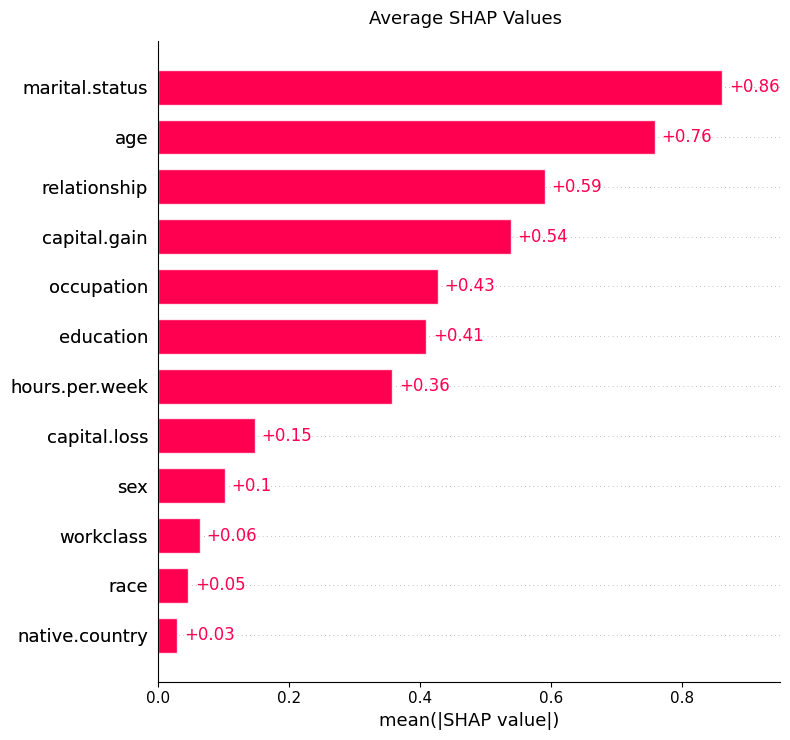

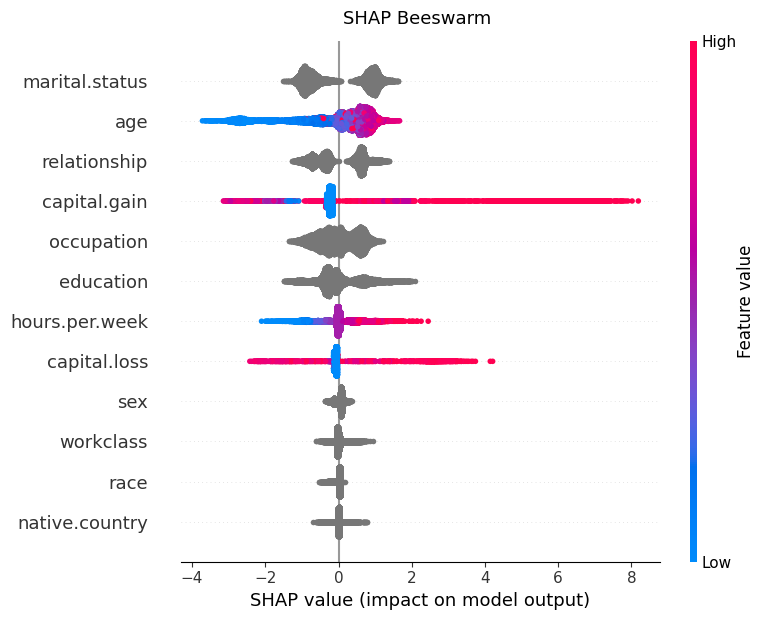

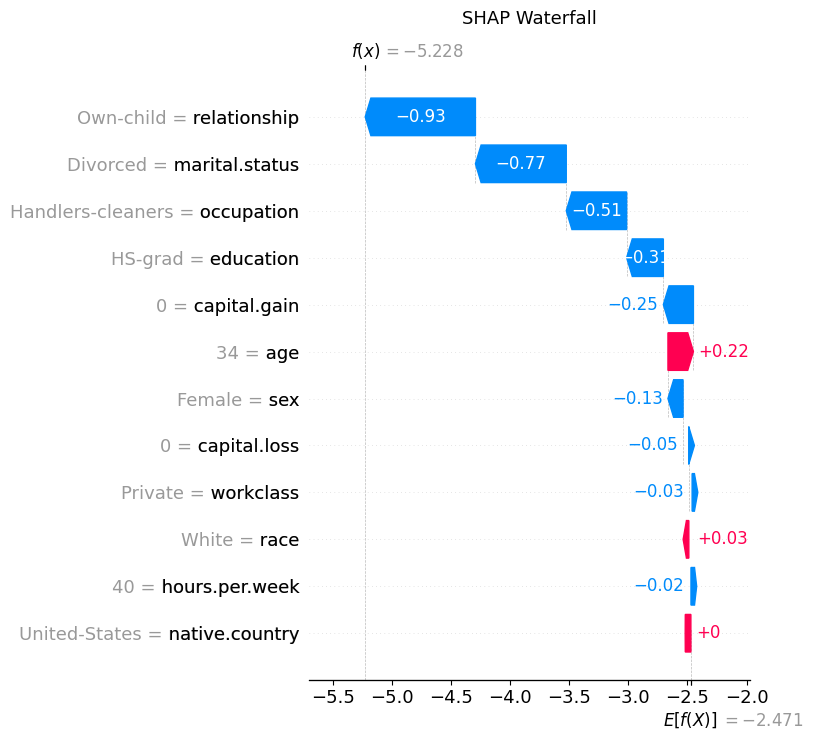

In [33]:
cat_cols.remove('income')
model_lgb=LGBMClassifier().set_params(**report['lgb']['best_params'])
model_lgb.fit(X_train,y_train,categorical_feature=cat_cols)
ml_utils.shap_bar_plot(model_lgb,X_train)
ml_utils.shap_beeswarm_plot(model_lgb,X_train)
ml_utils.shap_waterfall_plot(model_lgb,X_train)

Here, we extract SHAP values using the LightGBM model and generate the visualizations using the functions defined in our ml_utils.py file. These plots allow us to gather insights about the overall features and their importance. For instance, in the SHAP bar plot, we can see that marital-status leads with an importance score of +0.86, followed by age, relationship, and so on, indicating that almost all features contribute positively to the model. At the very bottom, native-country stands at +0.03, which is likely due to it being a high-cardinality categorical feature that is also highly imbalanced, given that the vast majority of the dataset consists of "United-States".

Looking at the SHAP beeswarm and other plots yields similar conclusions; however, because some features are categorical, they appear in gray on the beeswarm plot, making them difficult to analyze properly there. Furthermore, we selected a single random data point (the default sample at index 0) and analyzed its waterfall plot. In this plot, relationship sits at the top with an impact of -0.93, followed by marital-status, and so on. This is completely expected, as feature rankings can vary from sample to sample, though not too drastically. Generally speaking, the most important global features will consistently remain near the top.

## Final Ensemble Model Construction (Voting Classifier)

In [34]:
estimators=[('KNN',KNeighborsClassifier().set_params(**report['knn']['best_params'])),
              ('Logistic Regression',LogisticRegression().set_params(**report['logreg']['best_params'])),
('LightGBM', LGBMClassifier().set_params(**report['lgb']['best_params'])),('XGBoost', XGBClassifier().set_params(**report['xgb']['best_params']))]


In [35]:
model=ml_utils.voting_classifier(estimators=estimators,voting='soft',cv_n=5,preprocessor_pipeline=preprocessing_pipeline,X=X_train , y=y_train)

Here, we select the best estimators to build a VotingClassifier. Inside this ensemble model, we include both XGBoost and LightGBM. We excluded CatBoost because it shares the same underlying logic as the other GBM models, achieved a lower score, and has the longest training time. Additionally, since they follow the same approach, they are prone to making the same types of errors. We also included KNN (which yielded a solid score and operates on a completely different logic, potentially capturing patterns that the tree-based models missed) and LogisticRegression (which performed reasonably well and serves as the best model to capture linear relationships within the data).

Note: This specific VotingClassifier configuration was chosen as the top performer after experimenting with several alternative model combinations, which is why we are utilizing it for our final pipeline.

## Model Evaluation and Performance Analysis

In [36]:
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

### Confusion Matrix and Classification Metrics

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4907
           1       0.79      0.68      0.73      1577

    accuracy                           0.88      6484
   macro avg       0.84      0.81      0.82      6484
weighted avg       0.87      0.88      0.87      6484



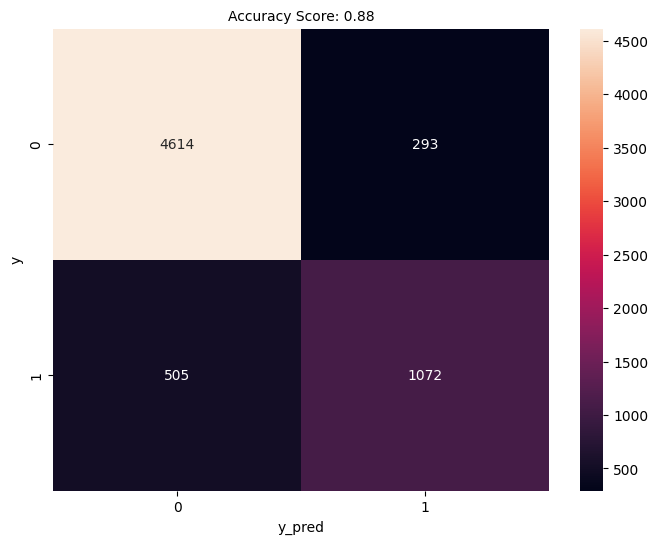

In [37]:
print(classification_report(y_test,y_pred))
ml_utils.confusion_matrix_plot(y_test,y_pred,height_for_plot=6,width_for_plot=8)

After training the model, we evaluate the confusion matrix and its corresponding metrics. We can observe that for class 0, the precision, recall, and F1-score are 0.90, 0.94, and 0.92, respectively. For class 1, these values are 0.79, 0.68, and 0.73. These metrics are genuinely solid. Naturally, the metrics for class 0 performed better because the majority of the dataset consists of class 0 samples. The overall accuracy stands at 0.88.

### ROC-AUC Curve

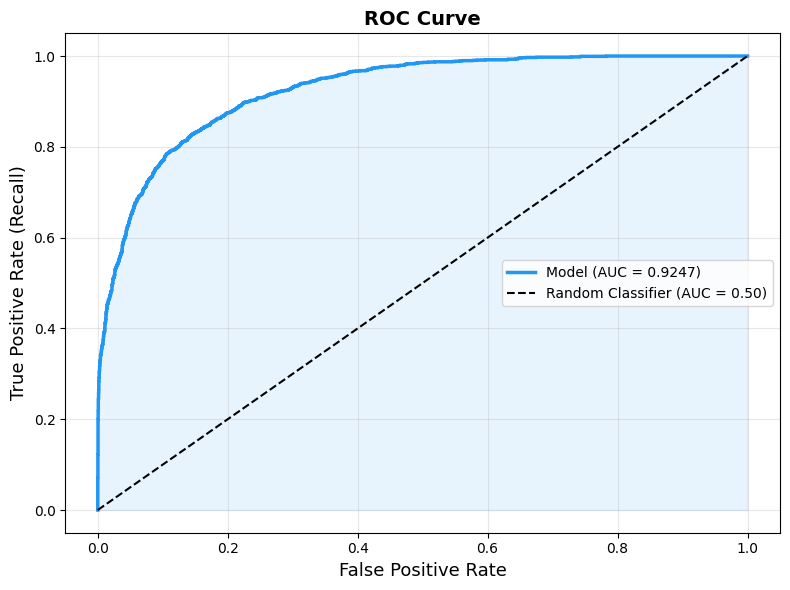

In [38]:
ml_utils.roc_curve_plot(model,X_test,y_test)

Here, we plot the ROC curve and obtain an AUC score of 0.92, which is highly satisfactory.

### Learning Curve Analysis

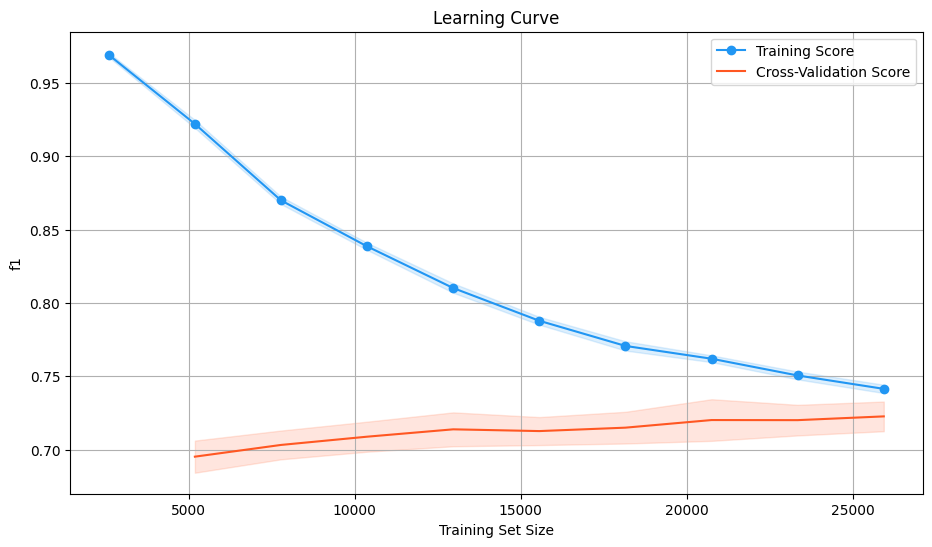

In [39]:
ml_utils.learning_curve_plot(model,X,y)

After analyzing the learning curve using our learning_curve plotting function, we can see that as the dataset size increases, the training score and the cross-validation test score (in terms of F1 score) converge as expected. This indicates that there are no anomalies, such as severe overfitting or underfitting. Our next step is to leverage these insights and results to build an end-to-end ML Pipeline encapsulated within a class structure (following OOP principles). Finally, we will fit the model on the full dataset to ensure it learns from all available data.